# A pairs Identification Framework using PCA, Ward-linkage, Agglomerative clustering, Correlation and cointegration testing, and finally OLS and half-life filters.

## Objective: To clearly show that intra sector correlation does not always imply cointegration (whether long or short term) and to provide a strict framework for through identification of pairs.

#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from statsmodels.tsa.stattools import coint
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import warnings
warnings.filterwarnings('ignore')

#### For example we take the XLK ETF's stocks--so technical universe

In [2]:
tickers = [
    "NVDA","AAPL","MSFT","AVGO","AMD","CSCO","IBM","ORCL","CRM","LRCX","AMAT",
    "QCOM","INTU","ACN","TXN","NOW","INTC","APH","ADBE","ADI","ANET","PANW","CDNS",
    "SNPS","GLW","TEL","ADSK","MSI","WDC","NXPI","FTNT","ROP","WDAY","MPWR","FICO",
    "CTSH","MCHP","HPE","TER","FSLR","TDY","JBL","ON","NTAP","HPQ","TYL","TRMB",
    "IT","CDW","GDDY","GEN","FFIV","SMCI","ZBRA","AKAM","EPAM","SWKS"
]

#### Use past 10 years yahoo finance data, returns will be normalized to account for extreme drawdown/crash periods.

In [3]:
df = yf.download(tickers=tickers,start='2015-01-01',auto_adjust=False,timeout=60,threads=False)


[*********************100%***********************]  57 of 57 completed


In [4]:
df.head()

Price       Adj Close                                                         \
Ticker           AAPL        ACN       ADBE        ADI       ADSK       AKAM   
Date                                                                           
2015-01-02  24.214899  74.252617  72.339996  44.216049  59.529999  63.250000   
2015-01-05  23.532726  72.998940  71.980003  43.411983  58.660000  61.939999   
2015-01-06  23.534931  72.472328  70.529999  42.392937  57.500000  60.669998   
2015-01-07  23.864950  73.993538  71.110001  42.838776  57.380001  60.160000   
2015-01-08  24.781900  75.121864  72.919998  43.595070  58.799999  61.570000   

Price                                             ...   Volume          \
Ticker           AMAT   AMD      ANET        APH  ...     SWKS     TDY   
Date                                              ...                    
2015-01-02  21.737469  2.67  3.917500  12.086214  ...  2850200  145700   
2015-01-05  21.040745  2.66  3.987500  11.865397  ...  2924500  266200   
2015-01-06  20.248240  2.63  3.988125  11.714437  ...  4746300  243000   
2015-01-07  20.439833  2.58  4.071250  11.914968  ...  2896200  245300   
2015-01-08  21.093002  2.61  4.132500  12.147048  ...  3773000  240300   

Price                                                                     \
Ticker          TEL      TER     TRMB      TXN     TYL     WDAY      WDC   
Date                                                                       
2015-01-02   948900  1030300  1106000  4020100  216200  1630000  1278547   
2015-01-05   953400  1877000  1254900  5599300  270300  1591400  2199752   
2015-01-06  1448800  2377700  2291600  5468400  239600  1584000  2665713   
2015-01-07  1929000   902400  2096400  4577100  220300  1106100  2054222   
2015-01-08  1635300  1626800  2036000  6295200  264700  2090100  3351291   

Price               
Ticker        ZBRA  
Date                
2015-01-02  411800  
2015-01-05  420300  
2015-01-06  527500  
2015-01-07  467800  
2015-01-08  324400  

[5 rows x 342 columns]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2821 entries, 2015-01-02 to 2026-03-23
Columns: 342 entries, ('Adj Close', 'AAPL') to ('Volume', 'ZBRA')
dtypes: float64(287), int64(55)
memory usage: 7.4 MB


Take the Log prices and get returns

In [6]:
# Log prices for cointegration later
log_prices = np.log(df['Adj Close'])

# Log returns for PCA and clustering
log_returns = log_prices.diff()


In [7]:
log_returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2821 entries, 2015-01-02 to 2026-03-23
Data columns (total 57 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2820 non-null   float64
 1   ACN     2820 non-null   float64
 2   ADBE    2820 non-null   float64
 3   ADI     2820 non-null   float64
 4   ADSK    2820 non-null   float64
 5   AKAM    2820 non-null   float64
 6   AMAT    2820 non-null   float64
 7   AMD     2820 non-null   float64
 8   ANET    2820 non-null   float64
 9   APH     2820 non-null   float64
 10  AVGO    2820 non-null   float64
 11  CDNS    2820 non-null   float64
 12  CDW     2820 non-null   float64
 13  CRM     2820 non-null   float64
 14  CSCO    2820 non-null   float64
 15  CTSH    2820 non-null   float64
 16  EPAM    2820 non-null   float64
 17  FFIV    2820 non-null   float64
 18  FICO    2820 non-null   float64
 19  FSLR    2820 non-null   float64
 20  FTNT    2820 non-null   float64
 21  GDDY    2760 non-nu

Divide into Train-Test sets for further actions.

In [8]:
# Train/test split on BOTH
train_returns = log_returns[:2300]
test_returns  = log_returns[2300:]

train_prices  = log_prices[:2300]
test_prices   = log_prices[2300:]

In [9]:
train_returns.dropna(inplace=True)
train_prices = train_prices.loc[train_returns.index]  #align index

In [10]:
train_returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2099 entries, 2015-10-20 to 2024-02-22
Data columns (total 57 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2099 non-null   float64
 1   ACN     2099 non-null   float64
 2   ADBE    2099 non-null   float64
 3   ADI     2099 non-null   float64
 4   ADSK    2099 non-null   float64
 5   AKAM    2099 non-null   float64
 6   AMAT    2099 non-null   float64
 7   AMD     2099 non-null   float64
 8   ANET    2099 non-null   float64
 9   APH     2099 non-null   float64
 10  AVGO    2099 non-null   float64
 11  CDNS    2099 non-null   float64
 12  CDW     2099 non-null   float64
 13  CRM     2099 non-null   float64
 14  CSCO    2099 non-null   float64
 15  CTSH    2099 non-null   float64
 16  EPAM    2099 non-null   float64
 17  FFIV    2099 non-null   float64
 18  FICO    2099 non-null   float64
 19  FSLR    2099 non-null   float64
 20  FTNT    2099 non-null   float64
 21  GDDY    2099 non-nu

Check for any missing rows/data.

In [11]:
# Check missing values in train returns
missing_df = (
    train_returns.isnull().sum()
      .reset_index()
      .rename(columns={"index": "Feature", 0: "Missing"})
)
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Missing", ascending=False)
missing_df

,Ticker,Missing


Normalize log returns for PCA

In [12]:
# Normalize returns for PCA
nor_t = (train_returns - train_returns.mean()) / train_returns.std()

In [13]:
# ── STAGE 1: Global PCA to remove market factor ──────────────────────────────
pca = PCA()
scores = pca.fit_transform(nor_t)

# Reconstruct market component (PC1 only)
pc1_scores    = scores[:, 0:1]                      # shape (T, 1)
pc1_loadings  = pca.components_[0:1, :]             # shape (1, N)
market_component = pc1_scores @ pc1_loadings        # shape (T, N)

# Residuals = market-neutral returns
residuals = nor_t.values - market_component
residuals_df = pd.DataFrame(residuals,
                             index=nor_t.index,
                             columns=nor_t.columns)

Scree plot to determine how many pricipal components to retain.

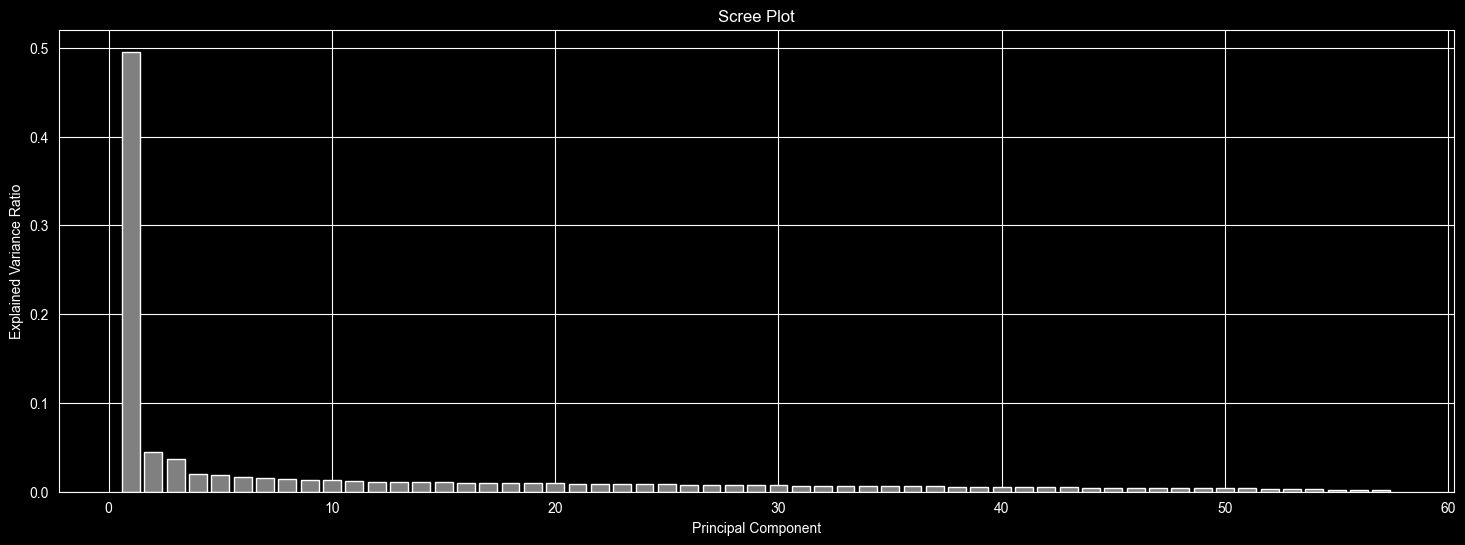

In [14]:
# Scree plot (unchanged)
explained_var = pca.explained_variance_ratio_
plt.figure(figsize=(18,6))
plt.bar(np.arange(1, len(explained_var) + 1), explained_var, color='grey')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.show()

Ticker
APH     0.158074
MCHP    0.157655
TXN     0.156881
ADI     0.156172
AMAT    0.154533
MPWR    0.154261
LRCX    0.153298
TEL     0.151152
MSFT    0.150998
SWKS    0.150410
SNPS    0.150357
INTU    0.148456
ACN     0.148134
CDNS    0.147762
TER     0.146931
AVGO    0.146733
ON      0.145071
ADBE    0.144073
ADSK    0.142416
NXPI    0.141967
AAPL    0.141750
NVDA    0.139583
CDW     0.138836
GLW     0.135663
JBL     0.134817
TRMB    0.134279
CRM     0.133872
FICO    0.133000
NOW     0.132898
QCOM    0.131876
INTC    0.131296
CSCO    0.130945
WDAY    0.128468
ROP     0.127764
CTSH    0.127647
TDY     0.126421
HPQ     0.124982
ZBRA    0.124626
FFIV    0.124471
WDC     0.124327
TYL     0.123270
IT      0.120366
NTAP    0.120267
GDDY    0.119549
MSI     0.119180
HPE     0.117918
FTNT    0.117719
ORCL    0.115226
ANET    0.115071
AMD     0.114080
EPAM    0.110680
IBM     0.109440
PANW    0.100772
AKAM    0.091614
FSLR    0.085731
SMCI    0.080661
GEN     0.075084
Name: 0, dtype: float64


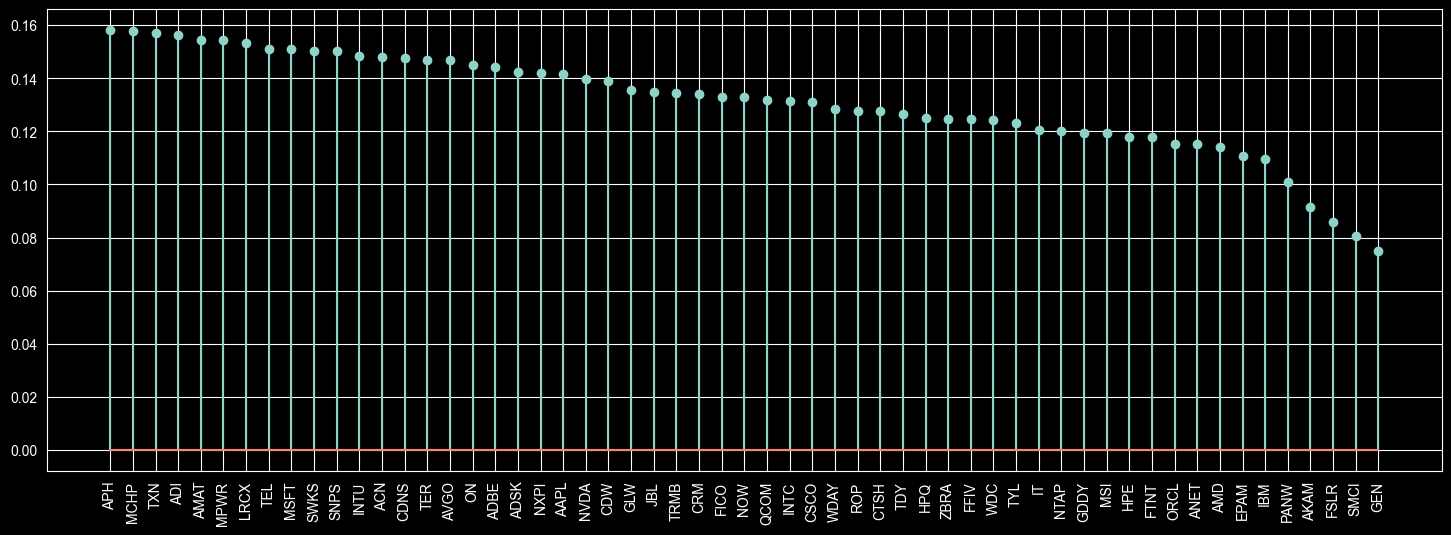

In [15]:
# PC1 loadings
loadings = pd.DataFrame(pca.components_.T, index=nor_t.columns)
pc1_load = loadings.iloc[:, 0].sort_values(key=abs, ascending=False)
print(pc1_load)
plt.figure(figsize=(18,6))
plt.stem(pc1_load.index, pc1_load.values)
plt.xticks(rotation=90)
plt.show()

Ticker
NOW     0.283571
CRM     0.242891
ADBE    0.239797
WDAY    0.236058
TYL     0.224262
HPE    -0.220049
PANW    0.200739
FTNT    0.191053
HPQ    -0.182119
INTU    0.180211
JBL    -0.180101
SNPS    0.176113
WDC    -0.172375
TEL    -0.165176
IBM    -0.163668
MSFT    0.158977
CDNS    0.156683
ON     -0.150304
NXPI   -0.148855
GLW    -0.146978
MCHP   -0.135950
ADSK    0.130202
NTAP   -0.126796
AKAM    0.126510
GDDY    0.123530
FICO    0.113461
ADI    -0.111718
APH    -0.111461
AMAT   -0.100942
TXN    -0.100409
TER    -0.096471
LRCX   -0.093769
SWKS   -0.092944
EPAM    0.090575
INTC   -0.084549
TDY    -0.083422
NVDA    0.082335
SMCI   -0.075859
ANET    0.075596
AVGO   -0.069402
CDW    -0.066025
GEN     0.058251
AAPL    0.058121
QCOM   -0.057488
CSCO   -0.050649
AMD     0.048366
TRMB   -0.046456
ORCL    0.044817
ACN     0.040631
CTSH   -0.038434
ZBRA   -0.030208
FSLR   -0.029215
FFIV   -0.029139
ROP     0.017103
MSI     0.015052
MPWR   -0.009249
IT      0.002249
Name: 1, dtype: float64


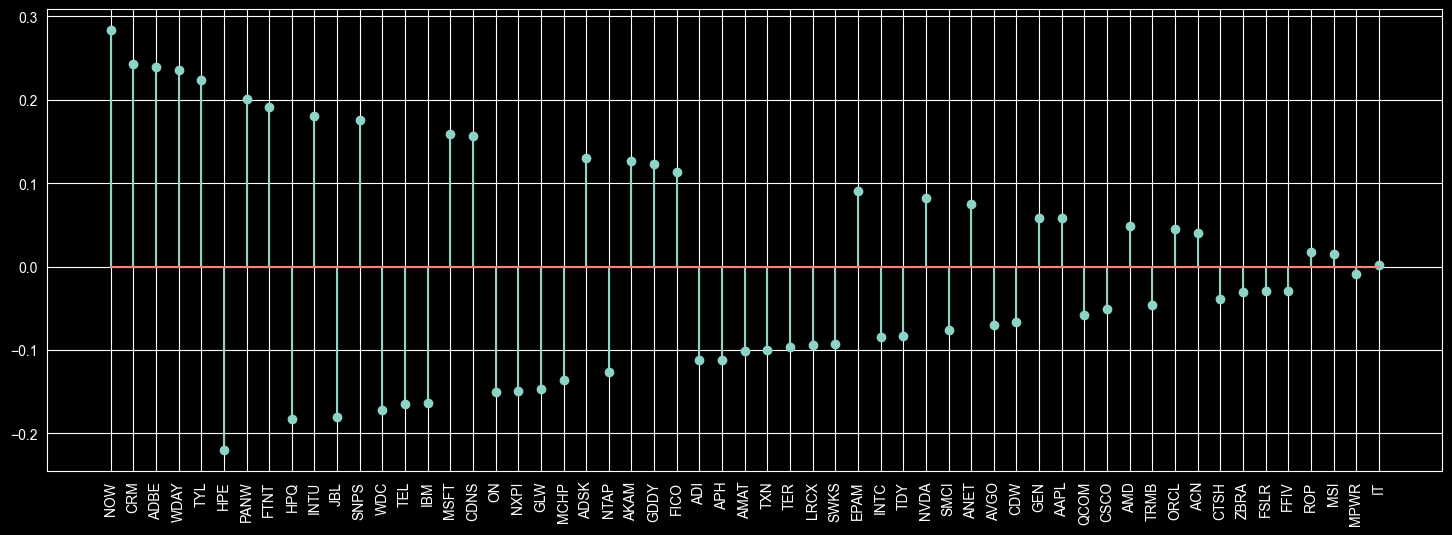

In [16]:
# PC2 loadings
pc2_load = loadings.iloc[:, 1].sort_values(key=abs, ascending=False)
print(pc2_load)
plt.figure(figsize=(18,6))
plt.stem(pc2_load.index, pc2_load.values)
plt.xticks(rotation=90)
plt.show()

Ward clustering on market neutral returns(residuals) from the PCA performed

In [17]:
# ── STAGE 2: Ward clustering on RESIDUALS ───────────────────
corr   = residuals_df.corr()
dist   = 1 - corr
distv  = squareform(dist.values)

link   = linkage(distv, method='ward')

model  = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(dist)
clusters = pd.Series(labels, index=nor_t.columns)
clusters.value_counts()

0    26
1    16
2    15
Name: count, dtype: int64

Dendrogram from agglomerative clustering

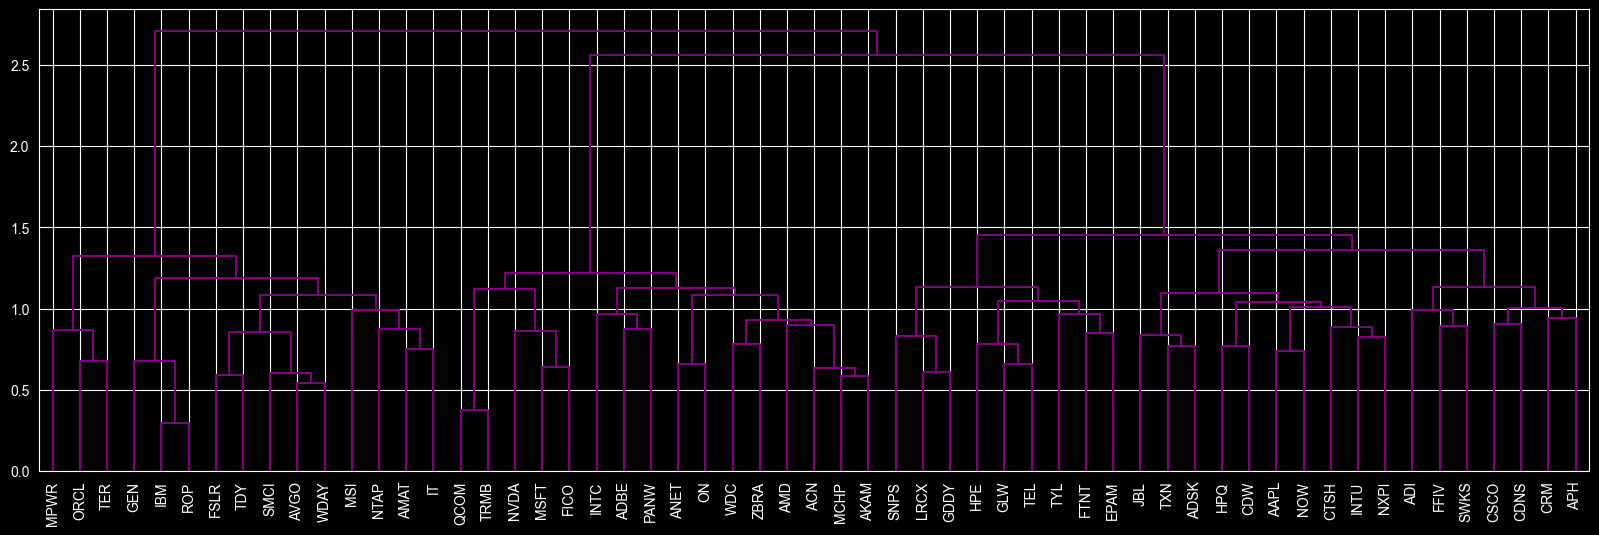

In [18]:
plt.figure(figsize=(20,6))
dendrogram(
    link,
    labels=tickers,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=False,
    above_threshold_color='purple'
)
plt.show()

Picking one cluster and performing PCA on it again

In [19]:
cluster_id = 1
cluster_stocks = clusters[clusters == cluster_id].index
cluster_stocks

Index(['ADI', 'AMAT', 'AMD', 'AVGO', 'INTC', 'LRCX', 'MCHP', 'MPWR', 'NVDA',
       'NXPI', 'ON', 'QCOM', 'SWKS', 'TER', 'TXN', 'WDC'],
      dtype='object', name='Ticker')

In [20]:
# Pick cluster for analysis
c1_returns = nor_t[cluster_stocks]
c1_prices  = train_prices[cluster_stocks]   # log prices for cointegration

In [21]:
c1_returns.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2099 entries, 2015-10-20 to 2024-02-22
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ADI     2099 non-null   float64
 1   AMAT    2099 non-null   float64
 2   AMD     2099 non-null   float64
 3   AVGO    2099 non-null   float64
 4   INTC    2099 non-null   float64
 5   LRCX    2099 non-null   float64
 6   MCHP    2099 non-null   float64
 7   MPWR    2099 non-null   float64
 8   NVDA    2099 non-null   float64
 9   NXPI    2099 non-null   float64
 10  ON      2099 non-null   float64
 11  QCOM    2099 non-null   float64
 12  SWKS    2099 non-null   float64
 13  TER     2099 non-null   float64
 14  TXN     2099 non-null   float64
 15  WDC     2099 non-null   float64
dtypes: float64(16)
memory usage: 278.8 KB


In [22]:
# ── STAGE 3: Cluster-level PCA + PC2 loading filter ──────────────────────────
newpca = PCA()
newpca.fit_transform(c1_returns)

array([[ 0.02400986,  0.53900421, -1.41534744, ...,  0.22045165,
         0.08215163, -0.3050713 ],
       [-0.60786987,  0.88347981, -0.85323431, ...,  1.33072142,
         0.50433522, -0.50786791],
       [ 5.90069699, -0.86609196, -3.07205979, ..., -2.12661193,
        -2.4627202 , -0.48277301],
       ...,
       [-1.72472973, -2.02458906, -0.3924977 , ..., -0.21030922,
         0.08249976, -0.77742901],
       [ 0.05736492, -0.77480649, -1.13880674, ...,  0.47684318,
         0.15361657,  0.20238623],
       [ 4.735311  ,  3.88355236,  1.11485547, ..., -0.69114617,
         0.18021324, -0.01094115]], shape=(2099, 16))

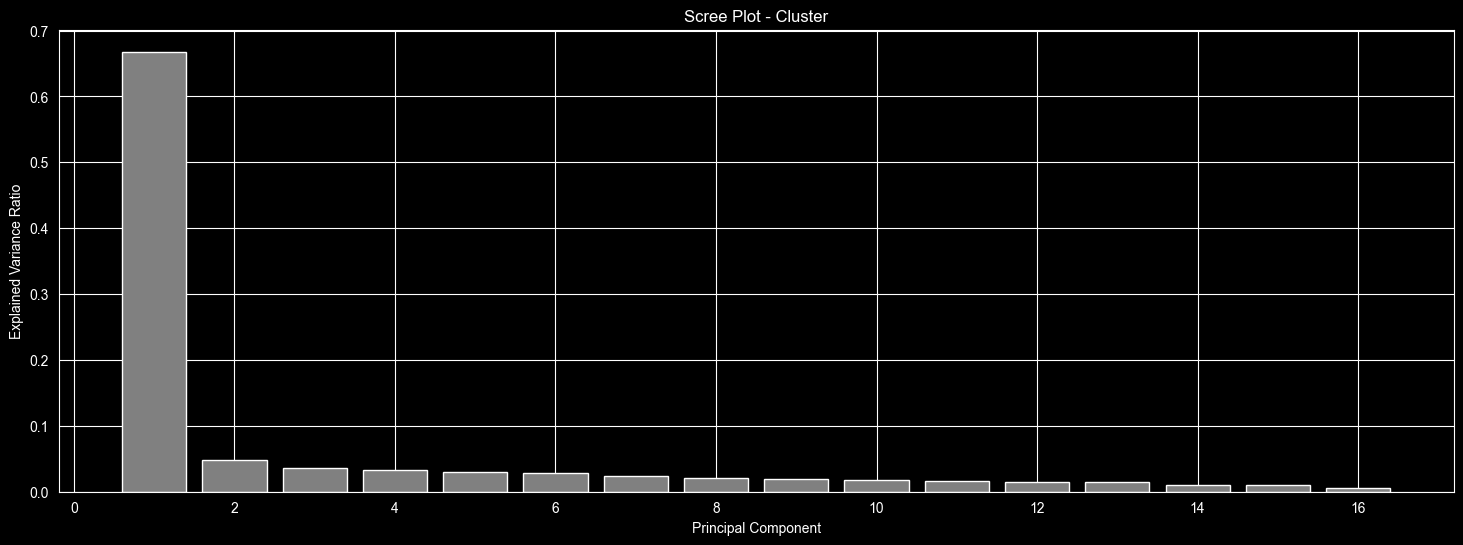

In [23]:
# Scree plot for cluster (unchanged)
explained_var_c1 = newpca.explained_variance_ratio_
plt.figure(figsize=(18,6))
plt.bar(np.arange(1, len(explained_var_c1) + 1), explained_var_c1, color='grey')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot - Cluster")
plt.show()

In [24]:
loadings_c1 = pd.DataFrame(newpca.components_.T, index=c1_returns.columns)
loadings_c1

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Ticker,,,,,,,,,,,,,,,,
ADI,0.272675,-0.114715,-0.184204,-0.051561,-0.035652,-0.165227,-0.053867,-0.021477,-0.252321,-0.263171,0.014644,-0.046679,0.215952,0.813041,0.031241,-0.000298
AMAT,0.271663,0.007859,0.193493,-0.009562,-0.322221,0.287654,-0.039765,-0.125838,0.167309,-0.262640,-0.016459,0.033715,-0.280166,0.034877,0.014097,0.711569
AMD,0.194491,0.749845,0.085338,-0.116798,0.149127,-0.270958,-0.367928,-0.369247,-0.005173,0.091323,-0.003777,0.041733,-0.034309,0.008796,0.015074,0.002516
AVGO,0.249757,-0.046368,-0.171065,0.002444,0.251405,0.044591,0.532724,-0.497078,0.436029,-0.048717,0.143092,0.121501,0.282483,-0.038733,0.025684,-0.020948
INTC,0.221582,-0.132540,0.256621,0.731867,-0.100501,-0.457354,-0.052145,0.066835,0.243432,0.165947,0.093156,-0.007025,-0.076242,0.059697,0.005892,-0.021356
LRCX,0.269074,-0.011271,0.217030,-0.073218,-0.366128,0.294482,-0.051287,-0.140250,0.142552,-0.184947,-0.019713,0.066528,-0.286584,0.056403,-0.067809,-0.694758
MCHP,0.275614,-0.122408,-0.110626,-0.078085,-0.101663,-0.172495,-0.092454,0.029070,-0.170492,-0.222145,0.127279,-0.055809,0.072834,-0.364094,0.776183,-0.056342
MPWR,0.261613,0.136336,-0.092554,-0.029008,-0.140557,0.048615,0.205249,0.242234,-0.321092,0.278516,0.465452,0.604783,-0.051921,-0.032683,-0.111080,0.038168
NVDA,0.232595,0.487557,0.032851,0.035304,0.040013,0.040074,0.461296,0.572862,0.111600,-0.137372,-0.221339,-0.274337,0.019764,0.026897,0.059982,-0.037428


Ticker
MCHP    0.275614
ADI     0.272675
AMAT    0.271663
LRCX    0.269074
TXN     0.268441
MPWR    0.261613
SWKS    0.259745
TER     0.258498
ON      0.257494
NXPI    0.250307
AVGO    0.249757
NVDA    0.232595
QCOM    0.227861
INTC    0.221582
WDC     0.210742
AMD     0.194491
Name: 0, dtype: float64


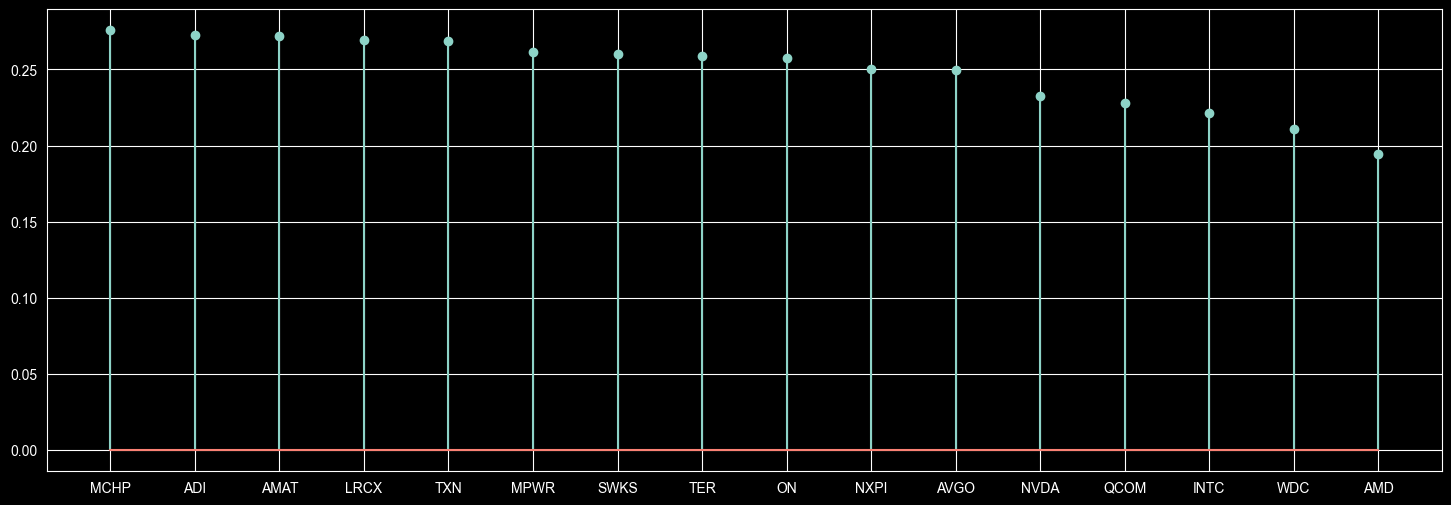

In [25]:
c1_pc1_load = loadings_c1.iloc[:, 0].sort_values(key=abs, ascending=False)
print(c1_pc1_load)
plt.figure(figsize=(18,6))
plt.stem(c1_pc1_load.index, c1_pc1_load.values)
plt.show()

Ticker
AMD     0.749845
NVDA    0.487557
WDC    -0.225858
NXPI   -0.204880
ON     -0.140179
MPWR    0.136336
INTC   -0.132540
MCHP   -0.122408
SWKS   -0.121529
ADI    -0.114715
TXN    -0.066246
AVGO   -0.046368
TER    -0.033474
QCOM    0.021654
LRCX   -0.011271
AMAT    0.007859
Name: 1, dtype: float64


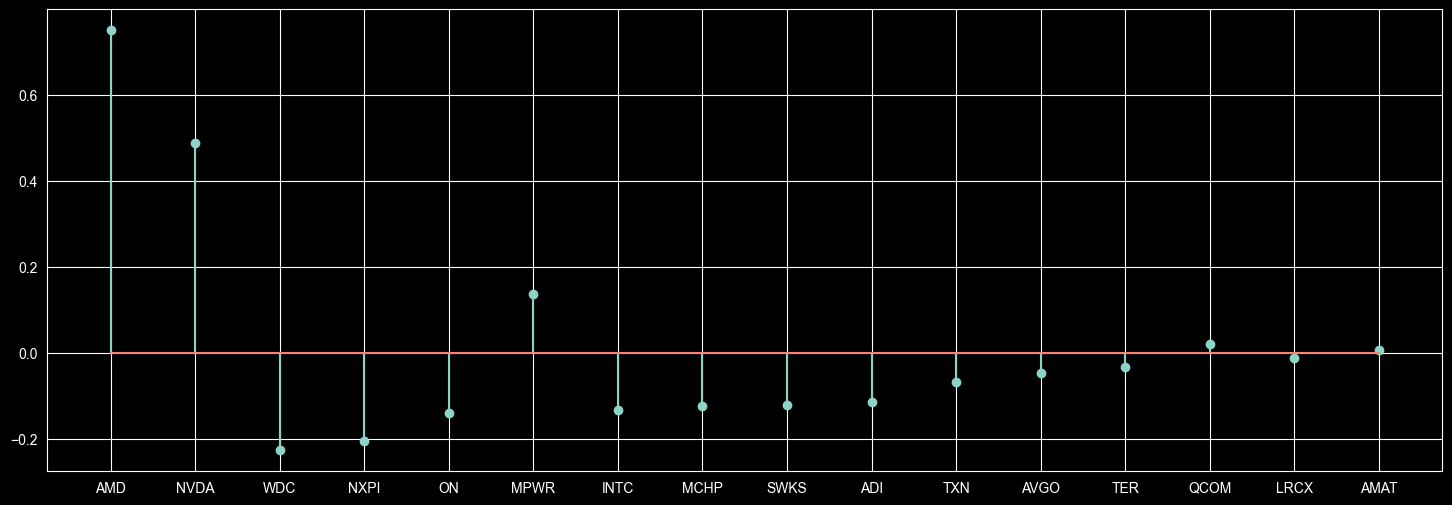

In [26]:
c1_pc2_load = loadings_c1.iloc[:, 1].sort_values(key=abs, ascending=False)
print(c1_pc2_load)
plt.figure(figsize=(18,6))
plt.stem(c1_pc2_load.index, c1_pc2_load.values)
plt.show()

In [27]:
# Filter candidates with |PC2 loading| > 0.15
prime_candi = c1_pc2_load[c1_pc2_load.abs() > 0.15].index
prime_candi

Index(['AMD', 'NVDA', 'WDC', 'NXPI'], dtype='object', name='Ticker')

In [28]:
# All unique pairs from candidates
pairs = []
for i in range(len(prime_candi)):
    for j in range(i+1, len(prime_candi)):
        pairs.append((prime_candi[i], prime_candi[j]))

Final Cointegration, hedge ratio and Half filter to get the absolute best pairs without any other identification, simple tradable pairs.

In [33]:
# ── STAGE 4 & 5: Cointegration on LOG PRICES + Half-life filter ──────────────
def hedge_ratio(y, x):
    x_c = sm.add_constant(x)
    model = sm.OLS(y, x_c).fit()
    return model.params[1]

pairs_info = []

for a, b in pairs:
    # Stage 4: Engle-Granger on log prices
    score, pvalue, _ = coint(c1_prices[a], c1_prices[b])
    if pvalue < 0.05: # We are getting resulting pairs for cointegration testing but the constraint is too loose(0.1-0.4), and even after that they are failing the half-life test.
        print(f'Cointegrated pair: ({a}, {b})  p-value: {pvalue:.4f}')

        # Stage 5: Half-life filter
        beta   = hedge_ratio(c1_prices[a], c1_prices[b])
        spread = c1_prices[a] - beta * c1_prices[b]

        spread_r   = spread.diff().dropna()
        spread_lag = spread.shift(1).dropna()

        reg      = sm.OLS(spread_r, sm.add_constant(spread_lag)).fit()
        halflife = -np.log(2) / reg.params.iloc[1]

        if 5 <= halflife <= 60:
            pairs_info.append({
                'A': a,
                'B': b,
                'beta': beta,
                'halflife': int(round(halflife))
            })

pairs_df = pd.DataFrame(pairs_info)
print(pairs_df)

Empty DataFrame
Columns: []
Index: []


# This means there is no pair left to trade on, there was this exact same case for the other Clusters 0 and 2 as well telling us that cluster has no tradable pairs within them.